### 앙상블
: 여러개의 분류 모델을 조합해서 더 나은 성능을 내는 방법

##### RandomForest
: 의사결정트리를 bagging(단일모델 조합)해서 예측을 실행하는 모델

In [3]:
# Library
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import koreanize_matplotlib
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
np.random.seed(5)

In [4]:
# 손글씨 데이터
mnist = datasets.load_digits()
features, labels = mnist.data, mnist.target

In [9]:
# 최적의 k를 찾기 위해 교차검증을 수행할 k의 범위를 3부터 학습데이터의 절반까지 지정
max_k_range = mnist.data.shape[0] // 2
max_k_range

898

In [10]:
k_list = [i for i in range(3, max_k_range, 2)]
k_list

[3,
 5,
 7,
 9,
 11,
 13,
 15,
 17,
 19,
 21,
 23,
 25,
 27,
 29,
 31,
 33,
 35,
 37,
 39,
 41,
 43,
 45,
 47,
 49,
 51,
 53,
 55,
 57,
 59,
 61,
 63,
 65,
 67,
 69,
 71,
 73,
 75,
 77,
 79,
 81,
 83,
 85,
 87,
 89,
 91,
 93,
 95,
 97,
 99,
 101,
 103,
 105,
 107,
 109,
 111,
 113,
 115,
 117,
 119,
 121,
 123,
 125,
 127,
 129,
 131,
 133,
 135,
 137,
 139,
 141,
 143,
 145,
 147,
 149,
 151,
 153,
 155,
 157,
 159,
 161,
 163,
 165,
 167,
 169,
 171,
 173,
 175,
 177,
 179,
 181,
 183,
 185,
 187,
 189,
 191,
 193,
 195,
 197,
 199,
 201,
 203,
 205,
 207,
 209,
 211,
 213,
 215,
 217,
 219,
 221,
 223,
 225,
 227,
 229,
 231,
 233,
 235,
 237,
 239,
 241,
 243,
 245,
 247,
 249,
 251,
 253,
 255,
 257,
 259,
 261,
 263,
 265,
 267,
 269,
 271,
 273,
 275,
 277,
 279,
 281,
 283,
 285,
 287,
 289,
 291,
 293,
 295,
 297,
 299,
 301,
 303,
 305,
 307,
 309,
 311,
 313,
 315,
 317,
 319,
 321,
 323,
 325,
 327,
 329,
 331,
 333,
 335,
 337,
 339,
 341,
 343,
 345,
 347,
 349,
 351,
 35

In [ ]:
# 의사결정 나무를 이용한 교차검증 10번 실시

# from sklearn.tree import DecisionTreeClassifier

# cv_scores = []

# for k in k_list:
#   clf = DecisionTreeClassifier()
#   scores = cross_val_score(
#     clf,
#     mnist.data,
#     mnist.target,
#     cv=10, # 10번 나눌꺼야
#     scoring='accuracy' # 정확도로 볼꺼야
#   )
#   cv_scores.append(scores.mean())

# cv_scores

[0.8291402855369336,
 0.8213500931098696,
 0.8230229671011793,
 0.8235692116697703,
 0.8330291744258224,
 0.8180136561142147,
 0.8224549968963377,
 0.8168963376784607,
 0.8257852265673493,
 0.8291371818746119,
 0.831368715083799,
 0.8196927374301677,
 0.8308100558659218,
 0.8285816263190565,
 0.8286002482929857,
 0.8347206703910615,
 0.8324829298572315,
 0.8263780260707636,
 0.83247982619491,
 0.8280260707635009,
 0.8380602110490379,
 0.8297051520794538,
 0.8252513966480446,
 0.8358472998137803,
 0.8207883302296709,
 0.8336095592799504,
 0.8185661080074489,
 0.8263687150837988,
 0.8257852265673495,
 0.8235443823711979,
 0.8319211669770329,
 0.8196741154562384,
 0.830800744878957,
 0.829143389199255,
 0.8252203600248293,
 0.8352451893234015,
 0.8318901303538174,
 0.8235847299813781,
 0.82971756672874,
 0.8274860335195531,
 0.8313656114214772,
 0.8347113594040968,
 0.8235630043451272,
 0.8224612042209808,
 0.8202358783364371,
 0.8252576039726878,
 0.8246710117939168,
 0.8219273743016761,

In [18]:
# 의사결정 나무를 이용한 교차검증 10번 실시

cv_scores = []

for _ in range(10):
  scores = cross_val_score(
    DecisionTreeClassifier(),
    features,
    labels,cv=10,
    scoring='accuracy'
  )

  cv_scores.append(scores.mean())

cv_scores

[0.8274891371818747,
 0.825235878336437,
 0.831368715083799,
 0.8196772191185598,
 0.8280477963997518,
 0.828038485412787,
 0.8285723153320917,
 0.8207976412166357,
 0.825788330229671,
 0.8302638112973308]

In [19]:
# RandomForest를 이용한 교차검증 10번 실시

cv_scores = []

for _ in range(10):
  scores = cross_val_score(
    RandomForestClassifier(),
    features,
    labels,cv=10,
    scoring='accuracy'
  )

  cv_scores.append(scores.mean())

cv_scores

[0.9526877715704531,
 0.9476908752327746,
 0.9454655493482308,
 0.9493482309124767,
 0.9510211049037863,
 0.9493482309124767,
 0.9471198013656114,
 0.9476784605834885,
 0.9493544382371197,
 0.951024208566108]

---
### 교차검증 함수 만들기

In [21]:
def cross_validation(classifier, features, label):
  cv_scores = []

  for _ in range(10):
    scores = cross_val_score(
      classifier,
      features,
      label,cv=10,
      scoring='accuracy'
    )

    cv_scores.append(scores.mean())

  return cv_scores

In [22]:
# 의사결정 나무
dt_cv_scores = cross_validation(DecisionTreeClassifier(), features, labels)

dt_cv_scores

[0.829143389199255,
 0.8274705152079453,
 0.8257976412166357,
 0.8352576039726877,
 0.8302358783364371,
 0.8269242706393545,
 0.8308162631905649,
 0.8280353817504655,
 0.8241402855369337,
 0.8219087523277467]

In [23]:
# Random Forest
rf_cv_scores = cross_validation(RandomForestClassifier(), features, labels)
rf_cv_scores

[0.9504748603351955,
 0.94768156424581,
 0.9460024829298572,
 0.9465704531346988,
 0.9465735567970205,
 0.9432216014897579,
 0.9499162011173183,
 0.9493575418994412,
 0.9482464307883302,
 0.9493544382371197]

### 랜덤포레스트와 의사결정나무의 정확도의 시각화

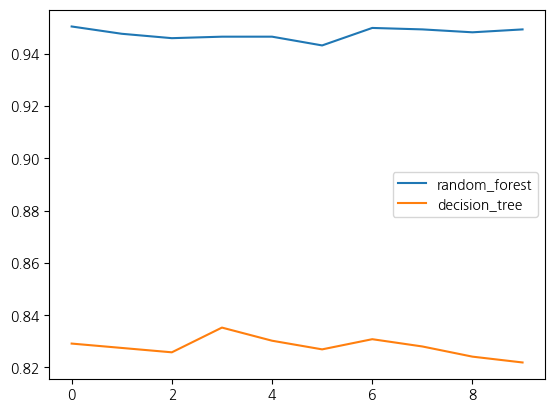

In [25]:
dv_list = {
  'random_forest' : rf_cv_scores,
  'decision_tree' : dt_cv_scores
}

df = pd.DataFrame(dv_list)
df.plot()
plt.show()

---
### 보팅(Voting) 앙상블
: 단일 모델을 앙상블하여 더 나은 예측을 하는 모델 생성

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier

In [27]:
train_data, test_data, train_target, test_target = \
  train_test_split(
    features,
    labels,
    random_state=42,
    stratify=labels,
    test_size=0.2
  )

### 단일 모델 정확도 측정

In [53]:
# Decision Tree
dtree = DecisionTreeClassifier()
dtree.fit(train_data, train_target)
print(dtree.score(train_data, train_target))
print(dtree.score(test_data, test_target))

1.0
0.8277777777777777


In [54]:
# KNN
knn = KNeighborsClassifier()
knn.fit(train_data, train_target)
print(knn.score(train_data, train_target))
print(knn.score(test_data, test_target))

0.9916492693110647
0.9833333333333333


In [58]:
# SVM
svm = SVC()
svm.fit(train_data, train_target)
print(svm.score(train_data, train_target))
print(svm.score(test_data,test_target))

0.9979123173277662
0.9916666666666667


### 하드보팅
: 각각의 분류기의 예측값들을 모아, 가장 많은 득표를 받은 예측값으로 최종 결론을 낸다.

In [59]:
voting_clf = VotingClassifier(
  estimators=[
    ('decision_tree',dtree),
    ('knn', knn),
    ('svm', svm),
  ],
  weights=[1,1,1],
  voting='hard'
).fit(train_data, train_target)

print(voting_clf.score(train_data, train_target))
print(voting_clf.score(test_data, test_target))

0.9979123173277662
0.9833333333333333


### 소프트 보팅
: 각각의 분류 모델을 활용하여 모든 분류값들의 확률들을 더해서 가장 높은 점수를 획득한 분류값으로 최종 결론을 내는 방식

In [60]:
# 소포트 보팅은 확률이 필요하므로 SVM에 확률 기능을 추가
svm = SVC(probability=True)

In [63]:
voting_clf = VotingClassifier(
  estimators=[
    ('decision_tree',dtree),
    ('knn', knn),
    ('svm', svm),
  ],
  weights=[1,1,1],
  voting='soft'
).fit(train_data, train_target)

print(voting_clf.score(train_data, train_target))
print(voting_clf.score(test_data, test_target))

0.9986082115518441
0.9777777777777777
